<h1> Data Science Project: Planning Stage (Individual) </h>

In [4]:
library(tidyverse)
library(repr)
options(repr.matrix.max.rows = 6)
source("cleanup.R")

Warning message in file(filename, "r", encoding = encoding):
“cannot open file 'cleanup.R': No such file or directory”


ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection


<h2> Data Description </h2>

In [5]:
player_data = read_csv('data/players.csv')
sessions_data = read_csv('data/sessions.csv')
player_data
sessions_data

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
⋮,⋮,⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,28/07/2024 15:36,28/07/2024 15:57,1.72218e+12,1.72218e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,25/07/2024 06:15,25/07/2024 06:22,1.72189e+12,1.72189e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,20/05/2024 02:26,20/05/2024 02:45,1.71617e+12,1.71617e+12


<h2> Number of Observations </h2>

In [6]:
observations_for_player_data = nrow(player_data)
observations_for_sessions_data = nrow(sessions_data)

observations_for_player_data
observations_for_sessions_data

[1] 196

[1] 1535

<h2> Number of Variables </h2>

In [7]:
variables_for_player_data = ncol(player_data)
vairables_for_sessions_data = ncol(sessions_data)
variables_for_player_data
vairables_for_sessions_data

[1] 7

[1] 5

<h2> Summary Statistics </h2>

In [8]:
time_difference = sessions_data |>
    mutate(original_time_difference = original_end_time - original_start_time)
  
max_min_avrg_sec_time_difference = time_difference |>
    summarize(max_time = max(original_time_difference / 1000, na.rm = TRUE),
             average_time = mean(original_time_difference / 1000, na.rm = TRUE),
             min_time = min(original_time_difference / 1000, na.rm = TRUE)) 

max_min_avrg_min_time_difference = mutate(max_min_avrg_sec_time_difference, 
                                          max_min_time = max_time / 60,
                                          average_min_time = average_time / 60,
                                          min_min_time = min_time / 60) |>
    select(max_min_time, average_min_time, min_min_time)

max_min_avrg_hour_time_difference = mutate(max_min_avrg_min_time_difference, 
                                          max_hour_time = max_min_time / 60,
                                          average_hour_time = average_min_time / 60,
                                          min_hour_time = min_min_time / 60) |>
    select(max_hour_time, average_hour_time, min_hour_time)

max_min_avrg_day_time_difference = mutate(max_min_avrg_hour_time_difference, 
                                          max_day_time = max_hour_time / 24,
                                          average_day_time = average_hour_time / 24,
                                          min_day_time = min_hour_time / 24) |>
    select(max_day_time, average_day_time, min_day_time)

max_min_avrg_sec_time_difference
max_min_avrg_min_time_difference
max_min_avrg_hour_time_difference
max_min_avrg_day_time_difference

max_time,average_time,min_time
<dbl>,<dbl>,<dbl>
20000,2909.328,0


max_min_time,average_min_time,min_min_time
<dbl>,<dbl>,<dbl>
333.3333,48.4888,0


max_hour_time,average_hour_time,min_hour_time
<dbl>,<dbl>,<dbl>
5.555556,0.8081467,0


max_day_time,average_day_time,min_day_time
<dbl>,<dbl>,<dbl>
0.2314815,0.03367278,0


<h2> Player Data </h2>

In [23]:
player_data

max_min_avrg_hours = player_data |>
    summarize(max_hours = max(played_hours, na.rm = TRUE),
             average_hours = mean(played_hours, na.rm = TRUE),
             min_hours = min(played_hours, na.rm = TRUE)) |>
    round(digits = 2)

max_min_avrg_age = player_data |>
    summarize(max_age = max(Age, na.rm = TRUE),
             average_age = mean(Age, na.rm = TRUE),
             min_age = min(Age, na.rm = TRUE)) |>
    round(digits = 2)

experiences_max_min_avrg_hours = player_data |>
    group_by(experience) |>
    summarize(max_hours = max(played_hours, na.rm = TRUE),
             average_hours = mean(played_hours, na.rm = TRUE),
             min_hours = min(played_hours, na.rm = TRUE)) |>
    mutate(max_hours = round(max_hours, digits = 2),
          average_hours = round(average_hours, digits = 2),
          min_hours = round(min_hours, digits = 2))

experiences_max_min_avrg_age = player_data |>
    group_by(experience) |>
    summarize(max_age = max(Age, na.rm = TRUE),
             average_age = mean(Age, na.rm = TRUE),
             min_age = min(Age, na.rm = TRUE)) |>
    mutate(max_age = round(max_age, digits = 2),
          average_age = round(average_age, digits = 2),
          min_age = round(min_age, digits = 2))

subscriber_max_min_avrg_hours = player_data |>
    group_by(subscribe) |>
    summarize(max_hours = max(played_hours, na.rm = TRUE),
             average_hours = mean(played_hours, na.rm = TRUE),
             min_hours = min(played_hours, na.rm = TRUE)) |>
    mutate(max_hours = round(max_hours, digits = 2),
          average_hours = round(average_hours, digits = 2),
          min_hours = round(min_hours, digits = 2))


number_of_subscribers = player_data |>
    group_by(experience) |>
    summarize(number_of_subscribers = sum(subscribe, na.rm = TRUE))


max_min_avrg_hours
max_min_avrg_age
experiences_max_min_avrg_hours
experiences_max_min_avrg_age
subscriber_max_min_avrg_hours
number_of_subscribers

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


max_hours,average_hours,min_hours
<dbl>,<dbl>,<dbl>
223.1,5.85,0


max_age,average_age,min_age
<dbl>,<dbl>,<dbl>
58,21.14,9


experience,max_hours,average_hours,min_hours
<chr>,<dbl>,<dbl>,<dbl>
Amateur,150.0,6.02,0
Beginner,23.7,1.25,0
Pro,30.3,2.60,0
Regular,223.1,18.21,0
Veteran,12.5,0.65,0


experience,max_age,average_age,min_age
<chr>,<dbl>,<dbl>,<dbl>
Amateur,57,21.37,11
Beginner,42,21.66,17
Pro,25,16.92,9
Regular,58,22.03,10
Veteran,46,20.96,16


subscribe,max_hours,average_hours,min_hours
<lgl>,<dbl>,<dbl>,<dbl>
FALSE,7.1,0.50,0
TRUE,223.1,7.78,0


experience,number_of_subscribers
<chr>,<int>
Amateur,45
Beginner,27
Pro,10
Regular,29
Veteran,33


Age,number_of_subscribers
<dbl>,<int>
9,1
10,1
11,1
⋮,⋮
57,0
58,1
NA,2


<h2> Summary Table </h2>

<h2> Sessions data </h2>

| Number of Observations  | Number of Variables 
| -------- | ------- | 
| 1535 | 5  |

| Name | Type |
| --- | --- |
| hasedEmail | chr |
| start_time | chr |
| end_time | chr |
| original_start_time | dbl
| original_end_time | dbl

<h3> Variable meaning </h3>
<p> - hashedEMail = ID of player <br>
- start_time = start time with date and time  <br>
- end_time = end time with date and time <br>
- original_start_time = start time in UNIX time (milliseconds) <br>
- original_ebd_time = end time in UNIX time (milliseconds) </p>

| Time Difference | Seconds | Minutes | Hours | Days
| -------------- | ---  | --- | --- | --- |
| max | 2e+07 | 333333.3 | 5555.556 | 231.4815
| average | 2909328 | 48488.8 | 808.1467 | 33.67278
| min | 0 | 0 | 0 | 0 



<h2> Player data </h2>

| Number of Observations  | Number of Variables 
| -------- | ------- | 
| 196 | 7  |

| Name | Type |
| --- | --- |
| Experience | chr |
| subscribe | lgl |
| hasedEmail | chr |
|played_hours| dbl
| name | chr
| gender | chr
|Age| dbl

<h3> Variable meaning </h3>
<p> - Experience = level of experience of player <br>
- subscribe = subscribed to a game-related newsletter <br>
- hashedEMail = ID of player <br>
- played_hours = hours played in game <br>
- name = name of participant <br>
- gender = gender of participant <br>
- Age = age of participant </p>

| Statistics | Hours played 
| --- | --- 
| max | 223.1
| average | 5.85	
| min | 0

| Statistics | Age
| --- | --- 
| max | 58
| average | 21.14	
| min | 9

|Experience | Max | Average | Min
| --- | --- | --- |--- 
| Beginner| 23.7 | 1.25 | 0
| Amateur| 150.0 | 	6.02 | 0
| Regular | 223.1 | 18.21 | 0
| Veteran | 12.5 |	0.65 | 0
| Pro | 30.3 | 2.60 | 0

|Experience | Max | Average | Min
| --- | --- | --- |--- 
| Beginner| 42 | 21.66 | 17
| Amateur| 57 | 	21.37 | 11
| Regular | 58 | 22.03 | 10
| Veteran | 46 |	20.96 |16
| Pro | 25 | 16.92 | 9


| Subscription | Max | Average | Min
| --- | --- | --- |--- 
| Yes| 7.1 | 0.50 | 0
| No| 223.1 | 	7.78 | 0

|Experience | Subscribers 
| --- | --- |
| Beginner| 45 |
| Amateur| 27 | 
| Regular | 10 | 
| Veteran | 29 |
| Pro | 33 | 


<h1> The Question </h1>

I will be finding which player characteristics and behabviours are most predictive of subscribing to a game related newletter, and how do these features differ 
between various player types specifcally if the age, experience and played hours of a player can predict if the person will subscribe in the player dataset. The player data set contains the expereience level, age and the amount of hours played as well as the response variable labelled subscribe. Experience and gender are factor vectors so I will convert them into numbers to represent the factor (ex. beginner = 1, amateur = 2, etc.) to use them as predictor variables. I can then isolate these 4 variables, make a model using kknn classification and use a trainng and test set to see if the model is accurate. I will produce plots to visualize the relationship between the predictor variables and the response variableas. 

<h1> Exporatory Data Analysis and Visualization </h1>

In [10]:
tidy_time = sessions_data |>
    separate(col = start_time,
             into = c('start_date', 'start_time'),
             sep = ' ') |>
    separate(col = end_time,
             into = c('end_date', 'end_time'),
             sep = ' ') 

tidy_player = player_data |>
    mutate(experience = as_factor(experience),
           gender = as_factor(gender), 
          Age = as.integer(Age))

tidy_time
tidy_player

hashedEmail,start_date,start_time,end_date,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024,18:12,30/06/2024,18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024,23:33,17/06/2024,23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024,17:34,25/07/2024,17:57,1.72193e+12,1.72193e+12
⋮,⋮,⋮,⋮,⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,28/07/2024,15:36,28/07/2024,15:57,1.72218e+12,1.72218e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,25/07/2024,06:15,25/07/2024,06:22,1.72189e+12,1.72189e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,20/05/2024,02:26,20/05/2024,02:45,1.71617e+12,1.71617e+12


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<fct>,<lgl>,<chr>,<dbl>,<chr>,<fct>,<int>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


<h2> Visualization </h2>

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


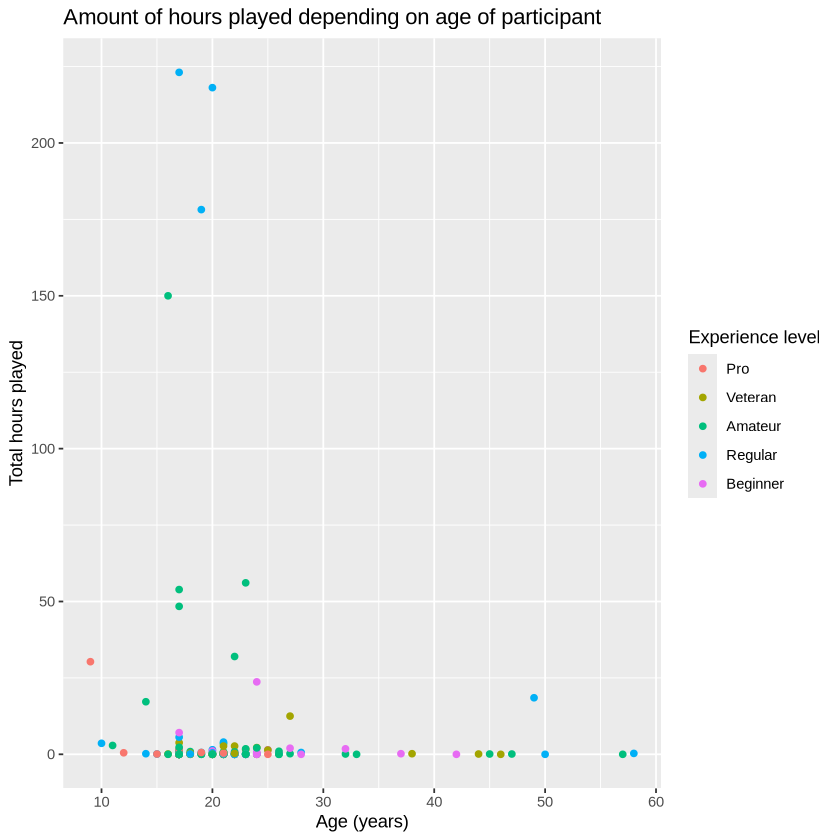

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


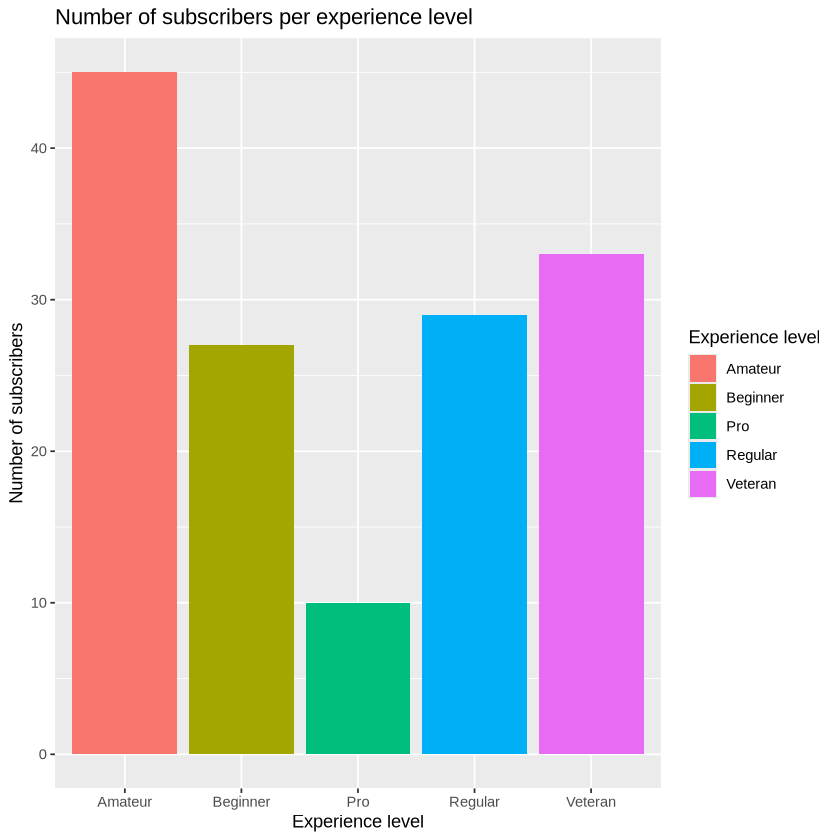

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


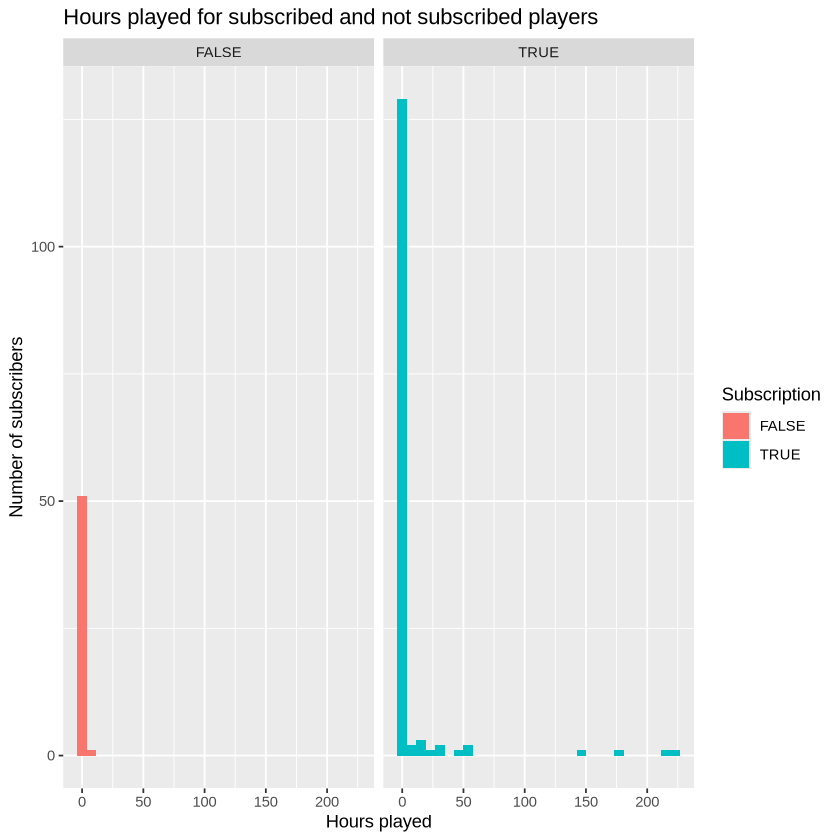

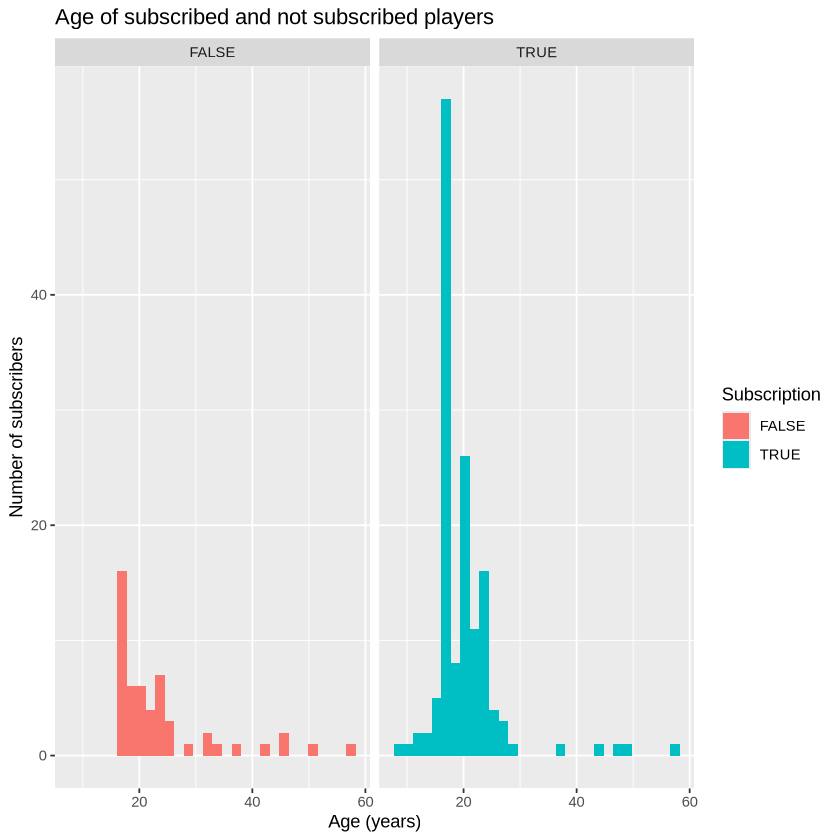

In [37]:
age_and_hours_plot = tidy_player |>
    ggplot(aes(x = Age, y = played_hours, color = experience)) +
    geom_point() +
    labs(x = 'Age (years)', y = 'Total hours played', color = 'Experience level') +
    ggtitle('Amount of hours played depending on age of participant')

subscribe_and_experience_plot = number_of_subscribers |>
    ggplot(aes(x = experience, y = number_of_subscribers, fill = experience)) +
    geom_bar(stat = 'identity') +
    labs(x = 'Experience level', y = 'Number of subscribers', fill = 'Experience level') +
    ggtitle('Number of subscribers per experience level')

subscribe_vs_hours_played = tidy_player |>
    ggplot(aes(x = played_hours, fill = subscribe)) +
    geom_histogram() +
    facet_grid(cols = vars(subscribe)) +
    labs(x = 'Hours played', y = 'Number of subscribers', fill = 'Subscription') +
    ggtitle('Hours played for subscribed and not subscribed players')

subscribe_vs_age = tidy_player |>
    ggplot(aes(x = Age, fill = subscribe)) +
    geom_histogram() +
    facet_grid(cols = vars(subscribe)) +
    labs(x = 'Age (years)', y = 'Number of subscribers', fill = 'Subscription') +
    ggtitle('Age of subscribed and not subscribed players')
               
age_and_hours_plot
subscribe_and_experience_plot
subscribe_vs_hours_played
subscribe_vs_age